# Customer lifetime value
### Jimmy Azar

## Introduction

The data consists of customer transaction information spanning over several years. There are 3 columns: the first represents customer ID, the second represents the amount purchased in dollars, and the third represents the date of purchase. We'll segment customers into groups, compute the transition matrix among the different segments, and use the transition matrix to predict yearly revenue for the next 10 years.

## Data exploration

We load and inspect the data. We also check the date range over which the data spans. For our task, the actual days and months of the transactions are not important - only the year is. So, we create a new column for 'year'.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# data exploration
path_to_file = '../data/transactions.txt'
data = pd.read_csv(path_to_file, sep='\t', header=None, names=['id','amount','date'])
data.head()
data.shape

data.describe()

data['date'] = pd.to_datetime(data['date'])

print(data['date'].min())
print(data['date'].max())

data['year'] = data['date'].dt.year  
data.head()

2005-01-02 00:00:00
2015-12-31 00:00:00


,id,amount,date,year
0,760,25.0,2009-11-06,2009
1,860,50.0,2012-09-28,2012
2,1200,100.0,2005-10-25,2005
3,1420,50.0,2009-07-09,2009
4,1940,70.0,2013-01-25,2013


## RFM Features

We'll need to define a set of features to derive from the dataset. In this context, three important features can be derived: recency, frequency, and monetary value (or amount). Given a customer (ID), recency is the time since that customer's last purchase, frequency is the number of times a purchase is made by that customer, and monetary value here can represent the average amount purchased and the maximum amount purchased.

We'll set January 1, 2016 as our current point in time. In order to derive recency, we compute the days elapsed from any given purchase date to this current date.

For each unique customer ID in the dataset, we use the entire data to derive recency, as well as days since the first purchase, in addition to the frequency of purchase, and the average amount purchased.

In [2]:
# RFM features
data['days_elapsed'] = (pd.to_datetime('2016-01-01') - data['date']).dt.days 

data_2015 = data.groupby(['id']).aggregate({'days_elapsed':['min', 'max'], 'id':'count', 'amount':'mean'})
data_2015.columns = ['recency','first_purchase','frequency','average_amount']
data_2015.head()

,recency,first_purchase,frequency,average_amount
id,,,,
10,3829,3829,1,30.000000
80,343,3751,7,71.428571
90,758,3783,10,115.800000
120,1401,1401,1,20.000000
130,2970,3710,2,50.000000


## Revenues 

First, we compute the total revenue for each (unique) customer ID for the year 2015. Note that if a certain customer hasn't made any purchase in 2015, the corresponding revenue should still be present and is equal to zero.

In [3]:
# revenues
rev_2015 = data[['id','amount']].copy()
rev_2015.loc[data['year']!=2015, 'amount'] = 0

rev_2015 = rev_2015.groupby(['id']).aggregate({'amount':'sum'})
rev_2015.columns = ['rev_2015']

print(rev_2015.head())

     rev_2015
id           
10        0.0
80       80.0
90        0.0
120       0.0
130       0.0


## Past data

We derived our set of features for the data in 2015. This is the most recent year we have in our dataset. Now, let's look at past data (particularly a year behind), and do the same for 2014. We should assume here that we are in 2014. So, we filter out the dataset accordingly at the outset, removing any data beyond 2014.

For each unique customer ID in the reduced dataset, we find the features we've derived before (recency, first purchase, frequency, and average amount).

In [4]:
# past data
data_2014 = data.copy().loc[data['days_elapsed']>365]

data_2014 = data_2014.groupby(['id']).aggregate({'days_elapsed':['min', 'max'], 'id':'count', 'amount':'mean'})
data_2014.columns = ['recency','first_purchase','frequency','average_amount']
data_2014[['recency','first_purchase']] -= 365 
data_2014.head()

,recency,first_purchase,frequency,average_amount
id,,,,
10,3464,3464,1,30.0
80,302,3386,6,70.0
90,393,3418,10,115.8
120,1036,1036,1,20.0
130,2605,3345,2,50.0


## Data merging

We now have features from 2014 in "data_2014" and revenues from 2015, "rev_2015". We merge these two data frames. We use a left join to merge based on the rows of the first data frame ("data_2014"). This ensures that only the customer IDs from 2014 appear in the merged data frame.

In [5]:
data_merged = pd.merge(data_2014, rev_2015, on='id', how='left')
print(data_merged.head())

     recency  first_purchase  frequency  average_amount  rev_2015
id                                                               
10      3464            3464          1            30.0       0.0
80       302            3386          6            70.0      80.0
90       393            3418         10           115.8       0.0
120     1036            1036          1            20.0       0.0
130     2605            3345          2            50.0       0.0


## Segmentation

Starting with "data_2015", we would like to segment it into the following clusters of interest, in a sequential manner.

In [6]:
df = pd.DataFrame({'Segment': ["A","B","C","D","E","F","G","H","I","J"],  
                   'Condition': ["recency > 365*3", "365*2 < recency <= 365*3",
                               "365 < recency <= 365*2", "recency <= 365",
                               "\"C\" AND first_purchase <= 365*2",
                               "\"C\" AND avg_amount < $100",
                               "\"C\" AND avg_amount >= $100",
                               "\"D\" AND first_purchase <= 365",
                               "\"D\" AND avg_amount < $100",
                               "\"D\" AND avg_amount >= $100"]})
print(df.to_string(index=False))

Segment                       Condition
      A                 recency > 365*3
      B        365*2 < recency <= 365*3
      C          365 < recency <= 365*2
      D                  recency <= 365
      E "C" AND first_purchase <= 365*2
      F       "C" AND avg_amount < $100
      G      "C" AND avg_amount >= $100
      H   "D" AND first_purchase <= 365
      I       "D" AND avg_amount < $100
      J      "D" AND avg_amount >= $100


We add a column named "cluster" to "data_2015" that represents the above segments. We also show the average feature values for each segment. 

We repeat the same segmentation process for "data_2014". Finally, we create a pie chart for the number of customers in each segment.

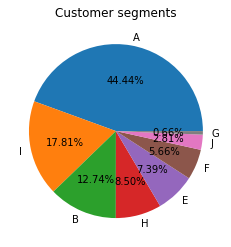

'A'

In [7]:
# segmentation
data_2015['cluster'] = np.nan
data_2015.loc[data_2015['recency']>365*3, 'cluster'] = 'A'
data_2015.loc[(data_2015['recency']>365*2) & (data_2015['recency']<=365*3), 'cluster'] = 'B'
data_2015.loc[(data_2015['recency']>365) & (data_2015['recency']<=365*2), 'cluster'] = 'C'
data_2015.loc[(data_2015['recency']<365), 'cluster'] = 'D'
data_2015.loc[(data_2015['cluster'] == 'C') & (data_2015['first_purchase'] <= 365*2), 'cluster'] = 'E'
data_2015.loc[(data_2015['cluster'] == 'C') & (data_2015['average_amount'] < 100), 'cluster'] = 'F'
data_2015.loc[(data_2015['cluster'] == 'C') & (data_2015['average_amount'] >= 100), 'cluster'] = 'G'
data_2015.loc[(data_2015['cluster'] == 'D') & (data_2015['first_purchase'] <= 365), 'cluster'] = 'H'
data_2015.loc[(data_2015['cluster'] == 'D') & (data_2015['average_amount'] < 100), 'cluster'] = 'I'
data_2015.loc[(data_2015['cluster'] == 'D') & (data_2015['average_amount'] >= 100), 'cluster'] = 'J'

data_2015.head()

data_2015['cluster'].value_counts().sort_index()
data_2015.groupby(['cluster']).mean()

data_2015['cluster'] = pd.Categorical(data_2015['cluster'], ['A','B','G','F','E','J','I','H'])  
data_2015.groupby(['cluster']).mean()

# same for data_2014 
data_2014['cluster'] = np.nan
data_2014.loc[data_2014['recency']>365*3, 'cluster'] = 'A'
data_2014.loc[(data_2014['recency']>365*2) & (data_2014['recency']<=365*3), 'cluster'] = 'B'
data_2014.loc[(data_2014['recency']>365) & (data_2014['recency']<=365*2), 'cluster'] = 'C'
data_2014.loc[(data_2014['recency']<365), 'cluster'] = 'D'
data_2014.loc[(data_2014['cluster'] == 'C') & (data_2014['first_purchase'] <= 365*2), 'cluster'] = 'E'
data_2014.loc[(data_2014['cluster'] == 'C') & (data_2014['average_amount'] < 100), 'cluster'] = 'F'
data_2014.loc[(data_2014['cluster'] == 'C') & (data_2014['average_amount'] >= 100), 'cluster'] = 'G'
data_2014.loc[(data_2014['cluster'] == 'D') & (data_2014['first_purchase'] <= 365), 'cluster'] = 'H'
data_2014.loc[(data_2014['cluster'] == 'D') & (data_2014['average_amount'] < 100), 'cluster'] = 'I'
data_2014.loc[(data_2014['cluster'] == 'D') & (data_2014['average_amount'] >= 100), 'cluster'] = 'J'

data_2014.head()

data_2014['cluster'].value_counts().sort_index()
data_2014.groupby(['cluster']).mean()

data_2014['cluster'] = pd.Categorical(data_2014['cluster'], ['A','B','G','F','E','J','I','H'])  
data_2014.groupby(['cluster']).mean()

df = data_2014['cluster'].value_counts()
plt.pie(df.values, labels=df.index, autopct='%0.2f%%') 
plt.title('Customer segments')
plt.show()

df.idxmax() # largest segment

## Revenue per cluster

We compute the average revenue (in 2015) per segment of customers (in 2014). This gives an idea of future revenues generated by each segment. We sort the clusters by decreasing revenue and generate a bar plot of the revenues per cluster.

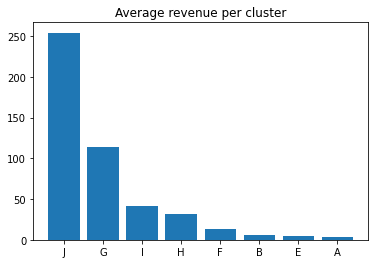

J


4

In [8]:
# revenue per cluster
df_rev = data_merged.groupby(data_2014['cluster']).aggregate({'rev_2015':'mean'}) 

df_rev = df_rev.sort_values(by='rev_2015', ascending=False)

plt.bar(df_rev.index, df_rev['rev_2015'])
plt.title('Average revenue per cluster')
plt.show()

print(df_rev['rev_2015'].idxmax()) # cluster with highest revenue

# rank of 'H'
(df_rev.index=='H').argmax() + 1

## Markov model

Next, we'll study how the different customer segments evolve from 2014 to 2015. That is, we need to compute the transition matrix showing the probability of moving from any given segment to another across one time step (i.e. 1 year). We begin by merging "data_2014" with "data_2015" keeping only customers appearing in 2014. In the merged data frame, every customer ID has a segment label in 2014 given by `cluster_x` and another segment label in 2015 given by `cluster_y`.

The data frame $M$ now contains the transition frequencies or counts from one segment to another. Strictly speaking, to create a transition matrix consisting of probabilities, we need to divide each row of the table by the row sum.

In [9]:
# Markov model
df = pd.merge(data_2014, data_2015, on='id', how='left')
df.head()

M = pd.crosstab(df['cluster_x'], df['cluster_y'])
M['H'] = 0 # force column 'H' to appear 
M = M.divide(M.sum(axis=1), axis='index')

print(M)
M.loc['A','A']
M.loc['H','E']

cluster_y         A         B         G         F         E         J  \
cluster_x                                                               
A          0.962061  0.000000  0.000000  0.000000  0.000000  0.004659   
B          0.896888  0.000000  0.000000  0.000000  0.000000  0.010218   
G          0.000000  0.675676  0.000000  0.000000  0.000000  0.315315   
F          0.000000  0.720711  0.000000  0.000000  0.000000  0.001046   
E          0.000000  0.911200  0.000000  0.000000  0.000000  0.012000   
J          0.000000  0.000000  0.250526  0.000000  0.000000  0.745263   
I          0.000000  0.000000  0.000000  0.299236  0.000000  0.007307   
H          0.000000  0.000000  0.000000  0.000000  0.652749  0.061935   

cluster_y         I    H  
cluster_x                 
A          0.033280  0.0  
B          0.092894  0.0  
G          0.009009  0.0  
F          0.278243  0.0  
E          0.076800  0.0  
J          0.004211  0.0  
I          0.693457  0.0  
H          0.285317  0.0  

0.6527487821851079

### Evolution of customer segments

Based on the transition matrix which we assume is fixed, we'll study the expected evolution of customer segments over a period of 10 years into the future, i.e. till 2025. We start by initializing a "clusters" data frame with segments as indices and years as columns. The data frame will indicate the changes in the number of customers in each segment across the years. Next, we populate the first column (year 2015) with the actual segment sizes which we have already from "data_2015" segments.

For each of the remaining columns, we use a *for* loop to sequentially compute the values of each column using matrix multiplication of the previous column by the probability transition matrix, $M$.

Finally, we create a bar plot showing the projected evolution in size (number of customers) of the group A segment across the years. We repeat this for group B. 

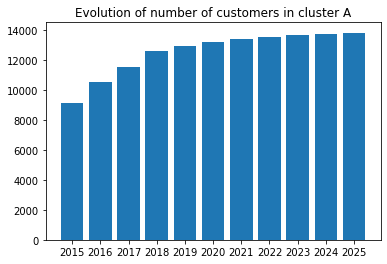

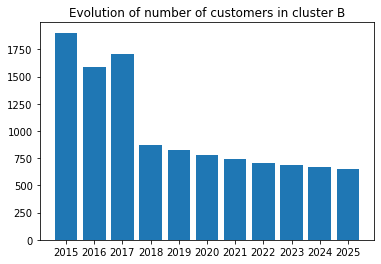

In [10]:
# evolution of customer segments
clusters = pd.DataFrame(np.nan, columns=range(2015,2025+1), index=['A','B','G','F','E','J','I','H'])
clusters[2015] = data_2015['cluster'].value_counts()

for year in range(2016,2025+1):
	clusters[year] = clusters[year-1].dot(M)

clusters.round()

plt.bar(range(len(clusters.columns)), clusters.loc['A',:])
plt.title('Evolution of number of customers in cluster A')
plt.xticks(ticks=range(11), labels=clusters.columns)
plt.show()

plt.bar(range(len(clusters.columns)), clusters.loc['B',:])
plt.title('Evolution of number of customers in cluster B')
plt.xticks(ticks=range(11), labels=clusters.columns)
plt.show()

## Yearly revenue per segment

Using "data_2015", we compute the average revenue in 2015 for each of the segments. We'll consider these values as fixed, based on the most recent year in our data (2015).

For each segment, we compute the yearly revenue by multiplying the average revenue for that segment by the number of customers in the segment across the years.

Next, we compute the total revenue in each year by summing across all segments. We show these total yearly revenues after rounding to whole numbers, and we create a bar plot displaying the total revenue for each year. Finally, we compute the cumulative yearly revenues and show these in a bar plot.

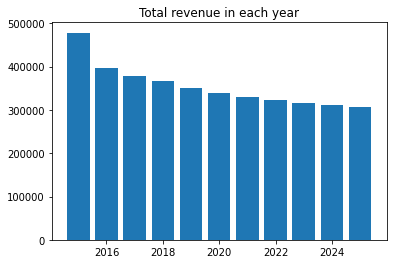

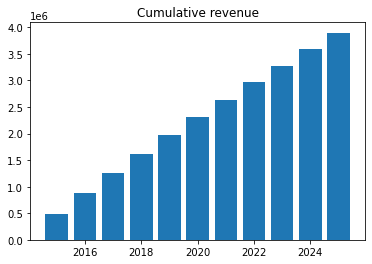

In [11]:
# yearly revenue per segment
rev_yearly = rev_2015.groupby(data_2015['cluster']).aggregate({'rev_2015':'mean'})

rev_per_cluster = clusters.multiply(rev_yearly['rev_2015'], axis='index')

rev_per_cluster.sum(axis=0).round()

plt.bar(rev_per_cluster.sum(axis=0).index, rev_per_cluster.sum(axis=0))
plt.title('Total revenue in each year')
plt.show()

rev_per_cluster.sum(axis=0).cumsum();

plt.bar(rev_per_cluster.sum(axis=0).cumsum().index, rev_per_cluster.sum(axis=0).cumsum())
plt.title('Cumulative revenue')
plt.show()

## Accounting for interest rate

In the previous computation of projected yearly revenues, we haven't accounted for the fact that $x$ dollars in the future is worth less than $x$ dollars today. In other words, we need to consider the effect of (compound) interest as a discount rate. We transform future values into present worth using: $P = F/(1+i)^n$, where $i$ is the interest rate and $n$ is the number of years. We suppose an interest rate of 10\% ($i=0.1$), and we compute the resulting present worth values of a dollar generated $n$ years from now, where $n$ spans from 0 to 10 years. These will be our discount factors. 

We re-compute the total yearly revenues taking interest rate into account. We show the numbers after rounding and plot these in a bar plot. Also, we compute the cumulative revenues and show these in a bar plot.

Finally, we compute the business worth for this study period which spans 10 years. This shows the amount of revenue expected to be generated throughout this period (in dollars).

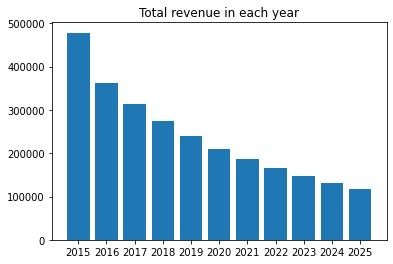

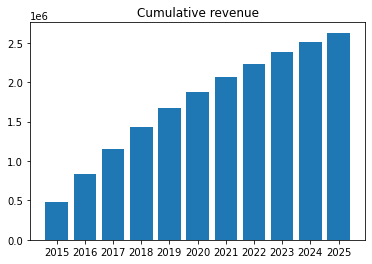

2150564.2937742346

In [12]:
# accounting for interest rate
i = 0.1 
P = 1 / ((1 + i)**np.arange(0,11))

total_rev_yearly_disc = rev_per_cluster.sum(axis=0) * P

plt.bar(range(11), total_rev_yearly_disc)
plt.xticks(ticks=range(11), labels=clusters.columns)
plt.title('Total revenue in each year')
plt.show()

total_cumul_disc = total_rev_yearly_disc.cumsum()

plt.bar(range(11), total_cumul_disc)
plt.xticks(ticks=range(11), labels=clusters.columns)
plt.title('Cumulative revenue')
plt.show()

# business worth (expected revenue over this period)
total_cumul_disc.iloc[-1] - total_cumul_disc.iloc[0]